# Harrys path to learn qiskit

In [1]:
%pip install -r requirements.txt


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from qiskit import QuantumCircuit

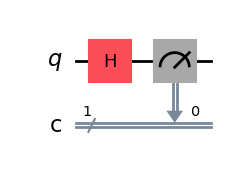

In [15]:
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0,0)
qc.draw("mpl")


# Adder circuit

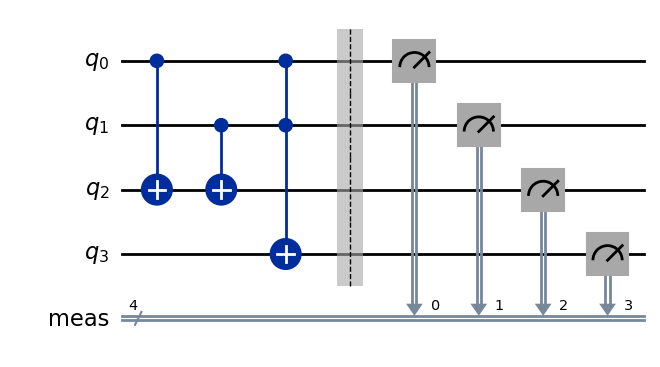

In [17]:
qc = QuantumCircuit(4)

a = 0
b = 0

if a:
    qc.x(0)
if b:
    qc.x(1)

qc.cx(0, 2)
qc.cx(1, 2)

qc.ccx(0, 1, 3)

qc.measure_all()

qc.draw("mpl")

In [23]:
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.visualization import plot_histogram

Local Noisy Counts: {'0000': 1004, '0001': 4, '1000': 9, '0100': 7}


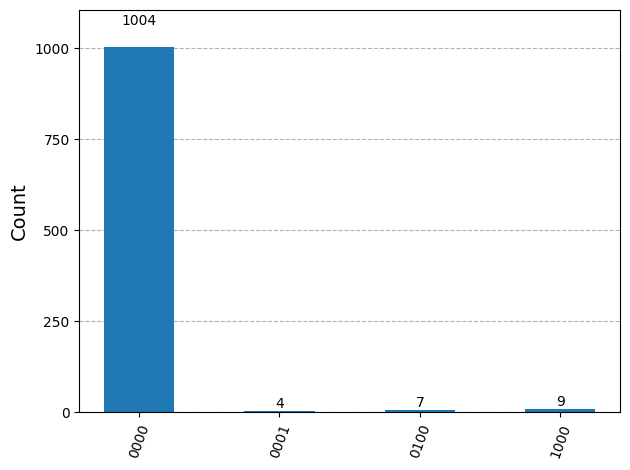

In [25]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# 1. Define the local mock backend to provide a realistic noise model
backend = GenericBackendV2(num_qubits=4)

# 2. Transpile the circuit to the backend's native ISA (Instruction Set Architecture)
# This maps the generic gates to the gates actually supported by the backend
pass_manager = generate_preset_pass_manager(optimization_level=1, target=backend.target)
isa_qc = pass_manager.run(qc)

# 3. Use AerSampler constructed from your local fake backend
# The AerSampler will automatically pull the noise model and constraints from the backend
sampler = AerSampler.from_backend(backend)
# If you want to force density_matrix, you can supply options:
# sampler.options.simulator = {"method": "density_matrix"}

# 4. Run the job on the noisy sampler using the transpiled ISA circuit
job = sampler.run([isa_qc], shots=1024)
result = job.result()

# 5. Get results
counts = result[0].data.meas.get_counts()
print("Local Noisy Counts:", counts)
plot_histogram(counts)